In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

In [4]:
df = pd.read_csv("/content/drive/MyDrive/Data Science/Data_set.csv")
df

,show_name,country,num_episodes,aired_on,original_network,rating,current_overall_rank,lifetime_popularity_rank,watchers
0,NaN,South Korea,16,"Friday, Saturday",tvN,8.9,33.0,1,111706.0
1,NaN,South Korea,16,"Friday, Saturday",jTBC,8.7,89.0,2,100950.0
2,Descendants of the Sun,South Korea,16,"Wednesday, Thursday",KBS2,8.7,77.0,3,96318.0
3,Boys Over Flowers,South Korea,25,"Monday, Tuesday",KBS2,7.7,2249.0,4,94228.0
4,W,South Korea,16,"Wednesday, Thursday",MBC,8.5,201.0,5,92121.0
...,...,...,...,...,...,...,...,...,...
95,Shut Up: Flower Boy Band,South Korea,16,"Monday, Tuesday",tvN,8.1,806.0,99,34668.0
96,Blood,South Korea,20,"Monday, Tuesday",KBS2,7.4,3271.0,100,34666.0
97,Chicago Typewriter,South Korea,16,"Friday, Saturday",tvN,8.8,51.0,101,NaN
98,Sungkyunkwan Scandal,South Korea,20,"Monday, Tuesday",KBS2,8.2,605.0,102,34615.0


In [5]:
print("Dataset Information")
df.info()

print("\nStatistical Summary")
print(df.describe(include='all'))

print("\nFirst 5 Rows")
print(df.head())

print("\nLast 5 Rows")
print(df.tail())

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   show_name                 96 non-null     object 
 1   country                   100 non-null    object 
 2   num_episodes              100 non-null    int64  
 3   aired_on                  99 non-null     object 
 4   original_network          99 non-null     object 
 5   rating                    96 non-null     float64
 6   current_overall_rank      97 non-null     float64
 7   lifetime_popularity_rank  100 non-null    int64  
 8   watchers                  97 non-null     float64
dtypes: float64(3), int64(2), object(4)
memory usage: 7.2+ KB

Statistical Summary
                     show_name      country  num_episodes  \
count                       96          100    100.000000   
unique                      96            3           NaN   
top   

In [6]:
print("Null Values")
print(df.isnull())

print("\nNull Count")
print(df.isnull().sum())

print("\nAfter Dropping Null Values")
print(df.dropna())

print("\nFill Null Values with 'O'")
print(df.fillna("O"))

print("\nForward Fill")
print(df.fillna(method="ffill"))

print("\nBackward Fill")
print(df.fillna(method="bfill"))

Null Values
    show_name  country  num_episodes  aired_on  original_network  rating  \
0        True    False         False     False             False   False   
1        True    False         False     False             False   False   
2       False    False         False     False             False   False   
3       False    False         False     False             False   False   
4       False    False         False     False             False   False   
..        ...      ...           ...       ...               ...     ...   
95      False    False         False     False             False   False   
96      False    False         False     False             False   False   
97      False    False         False     False             False   False   
98      False    False         False     False             False   False   
99      False    False         False     False             False   False   

    current_overall_rank  lifetime_popularity_rank  watchers  
0           

/tmp/ipykernel_3370/84686528.py:14: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  print(df.fillna(method="ffill"))
/tmp/ipykernel_3370/84686528.py:17: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  print(df.fillna(method="bfill"))


In [7]:
mean_df = df.copy()

numeric_columns = mean_df.select_dtypes(include=np.number).columns

for col in numeric_columns:
    mean_df[col].fillna(mean_df[col].mean(), inplace=True)

print(mean_df)

print("\nAfter Dropping Remaining Null Values")
print(mean_df.dropna())

                   show_name      country  num_episodes             aired_on  \
0                        NaN  South Korea            16     Friday, Saturday   
1                        NaN  South Korea            16     Friday, Saturday   
2     Descendants of the Sun  South Korea            16  Wednesday, Thursday   
3          Boys Over Flowers  South Korea            25      Monday, Tuesday   
4                          W  South Korea            16  Wednesday, Thursday   
..                       ...          ...           ...                  ...   
95  Shut Up: Flower Boy Band  South Korea            16      Monday, Tuesday   
96                     Blood  South Korea            20      Monday, Tuesday   
97        Chicago Typewriter  South Korea            16     Friday, Saturday   
98      Sungkyunkwan Scandal  South Korea            20      Monday, Tuesday   
99                  Vagabond  South Korea            16     Friday, Saturday   

   original_network  rating  current_ov

/tmp/ipykernel_3370/3427105153.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  mean_df[col].fillna(mean_df[col].mean(), inplace=True)


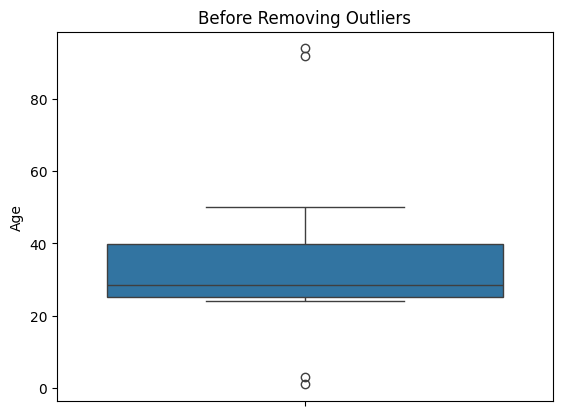

In [8]:
age = [1,3,28,27,25,92,30,39,40,50,26,24,29,94]
af = pd.DataFrame(age, columns=["Age"])

sns.boxplot(y=af["Age"])
plt.title("Before Removing Outliers")
plt.show()

Lower Limit: 3.5
Upper Limit: 61.5

Outliers
    Age
0     1
1     3
5    92
13   94

After Removing Outliers
    Age
2    28
3    27
4    25
6    30
7    39
8    40
9    50
10   26
11   24
12   29


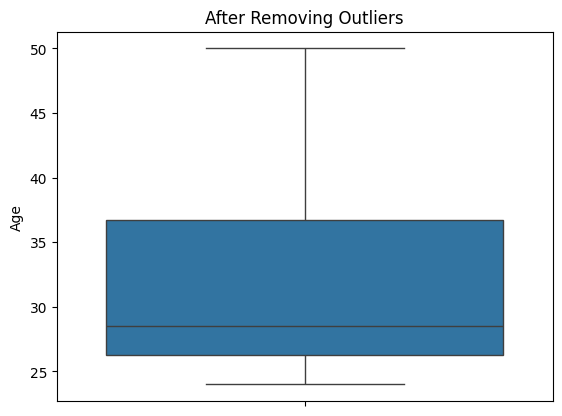

In [9]:
Q1 = af["Age"].quantile(0.25)
Q3 = af["Age"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower Limit:", lower)
print("Upper Limit:", upper)

outliers = af[(af["Age"] < lower) | (af["Age"] > upper)]

print("\nOutliers")
print(outliers)

af_clean = af[(af["Age"] >= lower) & (af["Age"] <= upper)]

print("\nAfter Removing Outliers")
print(af_clean)

sns.boxplot(y=af_clean["Age"])
plt.title("After Removing Outliers")
plt.show()

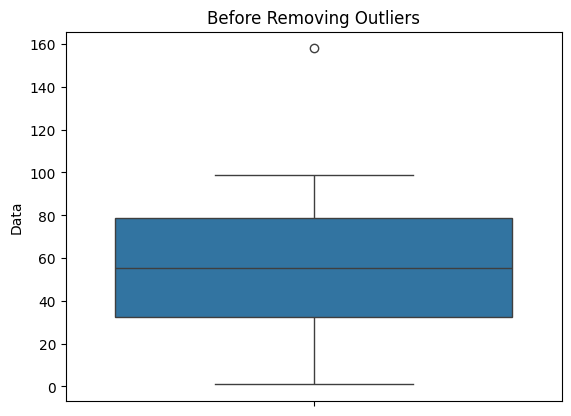

In [10]:
data = [1,12,15,18,21,24,27,30,33,36,39,42,45,48,51,54,57,60,63,66,69,72,75,78,81,84,87,90,93,96,99,158]

df2 = pd.DataFrame(data, columns=["Data"])

sns.boxplot(y=df2["Data"])
plt.title("Before Removing Outliers")
plt.show()

In [11]:
z = np.abs(stats.zscore(df2["Data"]))

print("Z Scores")
print(z)

outliers = df2[z > 3]

print("\nOutliers")
print(outliers)

df2_clean = df2[z <= 3]

print("\nAfter Removing Outliers")
print(df2_clean)

Z Scores
[1.72737516 1.38806932 1.29553137 1.20299341 1.11045546 1.0179175
 0.92537955 0.83284159 0.74030364 0.64776568 0.55522773 0.46268977
 0.37015182 0.27761386 0.18507591 0.09253795 0.         0.09253795
 0.18507591 0.27761386 0.37015182 0.46268977 0.55522773 0.64776568
 0.74030364 0.83284159 0.92537955 1.0179175  1.11045546 1.20299341
 1.29553137 3.11544448]

Outliers
    Data
31   158

After Removing Outliers
    Data
0      1
1     12
2     15
3     18
4     21
5     24
6     27
7     30
8     33
9     36
10    39
11    42
12    45
13    48
14    51
15    54
16    57
17    60
18    63
19    66
20    69
21    72
22    75
23    78
24    81
25    84
26    87
27    90
28    93
29    96
30    99


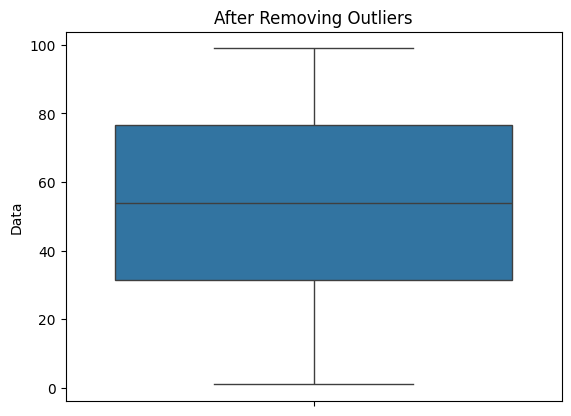

In [12]:
sns.boxplot(y=df2_clean["Data"])
plt.title("After Removing Outliers")
plt.show()